In [1]:
# Kütüphaneler ve görünüm ayarları
import os
import pandas as pd # veri okumak için
import matplotlib.pyplot as plt # grafik çizmek için

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)

In [ ]:
# Veri setini yükle
df = pd.read_csv("../data/train.csv")
df.head() # ilk 5 satırı göster

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


In [4]:
# Veri boyutu ve sütunlar
print("Veri boyutu:", df.shape)

print("\nSütunlar:")
print(df.columns.tolist())

Veri boyutu: (103904, 25)

Sütunlar:
['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


In [5]:
# Veri tipleri
print("Veri tipleri:")
print(df.dtypes)

Veri tipleri:
Unnamed: 0                             int64
id                                     int64
Gender                                   str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            in

In [6]:
# Eksik veri analizi
missing = df.isnull().sum().sort_values(ascending=False)

print("Eksik veri sayıları:")
print(missing)

Eksik veri sayıları:
Arrival Delay in Minutes             310
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Unnamed: 0                             0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Gate location                          0
Ease of Online booking                 0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
Food and drink                         0
On-board service                       0
Leg room service                       0
Checkin service                        0
Baggage handling                       0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes          

In [7]:
# Eksik veri tablosunu daha temiz göster
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ["column", "missing_count"]
missing_df

,column,missing_count
0,Arrival Delay in Minutes,310


In [8]:
# Hedef değişken dağılımı
print("Hedef değişken dağılımı:")
print(df["satisfaction"].value_counts())

print("\nHedef değişken oranları:")
print(df["satisfaction"].value_counts(normalize=True))

Hedef değişken dağılımı:
satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

Hedef değişken oranları:
satisfaction
neutral or dissatisfied    0.566667
satisfied                  0.433333
Name: proportion, dtype: float64


In [9]:
# Kategorik ve sayısal sütunları ayır
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_cols = df.select_dtypes(exclude=["object", "string"]).columns.tolist()

print("Kategorik sütunlar:")
print(categorical_cols)

print("\nSayısal sütunlar:")
print(numeric_cols)

Kategorik sütunlar:
['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

Sayısal sütunlar:
['Unnamed: 0', 'id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


In [10]:
# Sayısal özet
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,51951.500000,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Age,103904.0,39.379706,15.114964,7.0,27.00,40.0,51.00,85.0
Flight Distance,103904.0,1189.448375,997.147281,31.0,414.00,843.0,1743.00,4983.0
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.00,3.0,4.00,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.00,3.0,4.00,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.00,3.0,4.00,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.00,3.0,4.00,5.0


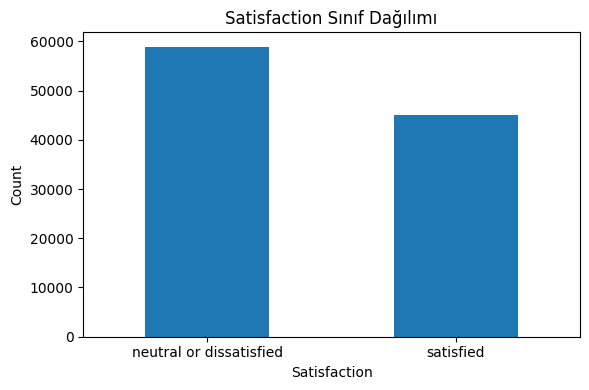

In [11]:
# Hedef değişken grafiği
class_counts = df["satisfaction"].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Satisfaction Sınıf Dağılımı")
plt.xlabel("Satisfaction")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/figures/class_distribution.png", dpi=300)
plt.show()

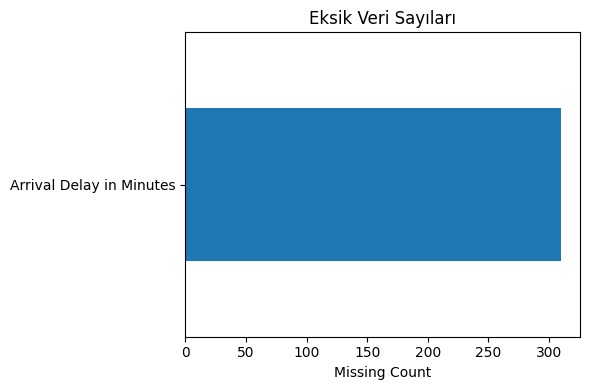

In [13]:
missing_nonzero = df.isnull().sum()
missing_nonzero = missing_nonzero[missing_nonzero > 0]

if len(missing_nonzero) > 0:
    plt.figure(figsize=(6, 4))
    missing_nonzero.sort_values().plot(kind="barh")
    plt.title("Eksik Veri Sayıları")
    plt.xlabel("Missing Count")
    plt.tight_layout()
    plt.savefig("../outputs/figures/missing_values.png", dpi=300)
    plt.show()
else:
    print("Eksik veri bulunmuyor.")

In [14]:
eda_summary = pd.DataFrame({
    "item": [
        "row_count",
        "column_count",
        "categorical_column_count",
        "numeric_column_count",
        "target_column",
        "missing_value_column_count"
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        len(categorical_cols),
        len(numeric_cols),
        "satisfaction",
        int((df.isnull().sum() > 0).sum())
    ]
})

eda_summary.to_csv("../outputs/tables/eda_summary.csv", index=False)
eda_summary

,item,value
0,row_count,103904
1,column_count,25
2,categorical_column_count,5
3,numeric_column_count,20
4,target_column,satisfaction
5,missing_value_column_count,1
